# Water demo


Water data from ISIS by Spencer Howell




In [3]:
# import needed modules
from MDMC.MD.interactions import Bond, BondAngle
from MDMC.control import Control
from MDMC.MD import *
from tests.test_data import data
from MDMC.gui import view
import os

In [4]:
# Change the number of threads for speed up
os.environ["OMP_NUM_THREADS"] = "4"

In [5]:
# Build universe
# Cubic universe of side:
# 18.6270199 A is 216 water molecules
# 21.731523217 is 343 water molecules
# 24.83602653 is 512 water molecules
universe = Universe(dimensions=21.75)
H1 = Atom('H')
H2 = Atom('H', position=(0., 1.63298, 0.))
O = Atom('O', position=(0., 0.81649, 0.57736))
# add interactions
H_coulombic = Coulombic(atoms=[H1, H2], cutoff=10.)
O_coulombic = Coulombic(atoms=O, cutoff=10.)
# create molecule using (the default) Harmonic Potential for the bonds
water_mol = Molecule(position=(0, 0, 0),
                     velocity=(0, 0, 0),
                     atoms=[H1, H2, O],
                     interactions=[Bond((H1, O), (H2, O), constrained=True),
                                   BondAngle(H1, O, H2, constrained=True)],
                     name='water')


Universe created with:
  Dimensions       [21.75, 21.75, 21.75]
  Force field                       None
  Number of atoms                      0



In [7]:
# add constraint algorithm for the constrained bonds
shake = Shake(1e-4, 100)
universe.constraint_algorithm = shake
e_solver = PPPM(accuracy=1e-5)
universe.electrostatic_solver = e_solver
# fill the universe with the molecule
universe.fill(water_mol, num_density=0.03356718472021752)
# add a dispersion between O atoms
O_dispersion = Dispersion(universe, (O.atom_type, O.atom_type), cutoff=10.,
                          vdw_tail_correction=True)
# apply SPCE force field
universe.add_force_field('SPCE')

In [9]:
# MD Engine setup
# NOTE: the temperatures of the measured data sets are:
# B Halle / ILL data: 263K; S Howells / ISIS data: 280K
# The below simulation object is for the ISIS data
simulation = Simulation(universe,
                        engine="lammps",
                        time_step=1.033916924,
                        temperature=280.,
                        traj_step=4000)


LAMMPS (29 Sep 2021 - Update 3)
  using 4 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
LAMMPS (29 Sep 2021 - Update 3)
  using 4 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
Total wall time: 0:00:00
using multi-threaded neighbor list subroutines
Simulation created with lammps engine and settings:
  temperature  280.0



In [12]:
# helper plotting function for plotting equilibration
import matplotlib.pyplot as plt
import numpy as np

def plot_vars(temperatures, potentials, line=0):
    plt.figure()
    plt.subplot(211)
    plt.plot(np.arange(len(temperatures))*10, temperatures)
    plt.ylabel('Temperature (K)')
    if line:
        plt.axvline(x=line, linestyle='--', color='lime')

    plt.subplot(212)
    plt.plot(np.arange(len(potentials))*10, potentials, color="orange")
    plt.xlabel('time (steps)')
    plt.ylabel('Potential energy (kcal/mol)')
    if line:
        plt.axvline(x=line, linestyle='--', color='lime')

    plt.show()

In [13]:
# Energy Minimization and equilibration
simulation.minimize(n_steps=500)
total_steps, vals_dict = simulation.auto_equilibrate()

Auto-equilibration has detected stability after 1640 equilibration steps.


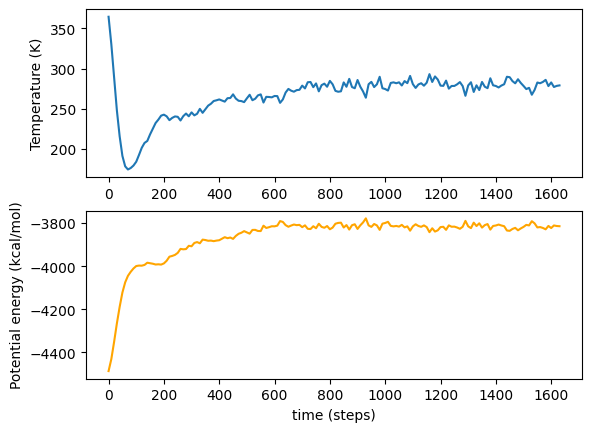

In [14]:
auto_temps = vals_dict['temp']
auto_potentials = vals_dict['pe']
plot_vars(auto_temps, auto_potentials)

In [23]:
# specify the data set and experimentally measured resolution (curtesy of Spencer Howell)
exp_dataset_ISIS = [{'file_name':os.getcwd()+'/data/IRIS_26176_water_data.dat',
                 'type':'SQw',
                 'reader':'MantidSQw',
                 'weight':1.,
                 'resolution':os.getcwd()+'/data/IRIS_26173_water_data_resolution.dat'}]

In [34]:
%matplotlib widget
# imports for reading in experimental data
from MDMC.trajectory_analysis.observables import SQw
from matplotlib.widgets import Slider
SQw_exp = SQw()
SQw_exp.read_from_file(reader="MantidSQw", file_name=exp_dataset_ISIS[0]['file_name'])
SQw=SQw_exp.SQw
Q = SQw_exp.Q
E = SQw_exp.E

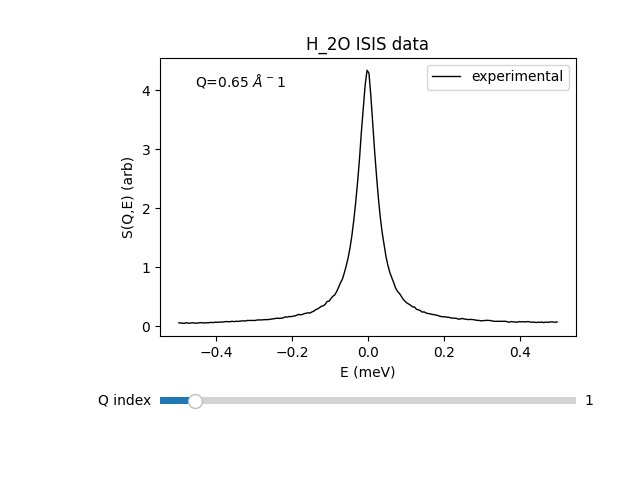

In [35]:
fig, ax = plt.subplots()
exp_line, = ax.plot(E, SQw[0,0,:], linewidth=1, color='black')
ax.legend(labels=['experimental'])
ax.set_xlabel('E (meV)')
ax.set_ylabel('S(Q,E) (arb)')
ax.set_title('H_2O ISIS data')

fig.subplots_adjust(left=0.25, bottom=0.3)
Q_slider_ax  = fig.add_axes([0.25, 0.15, 0.65, 0.03], facecolor='lightgoldenrodyellow')
Q_slider = Slider(Q_slider_ax, 'Q index', 0, len(Q)-1, valinit=1, valstep=1)
Q_label=plt.text(1,1.7,f'Q={Q[1]} $\AA^{-1}$')


def Q_on_changed(val):
    exp_line.set_ydata(SQw_exp[0,val])
    Q_label.set_text(f'Q={Q[val]} $\AA^{-1}$')
    fig.canvas.draw_idle()
    ax.set_ylim(0,max(np.max(SQw_exp[0,val])+0.1,1e-5))

Q_slider.on_changed(Q_on_changed)
plt.show()

this model has in general 7 (!) refinable parameters: 
- the charges on the atoms
- equilibrium values and potential strengths for the Harmonic Potentials for the Bond and BondAngle 
- sigma and epsilon of the Lennard Jones dispersion

In [37]:
# example: fix all parameters that are not in the Lennard Jones dispersion: 
for param in universe.parameters.as_array:
    if param.type not in ['epsilon', 'sigma']:
        param.fixed = True
fit_parameters = universe.parameters

In [38]:
# create the Control object to run the refinement
control = Control(simulation=simulation,
                  exp_datasets=exp_dataset_ISIS,
                  fit_parameters=fit_parameters,
                  minimizer_type="GPO",
                  MD_steps=804000,
                  equilibration_steps=2500)

TypeError: cannot unpack non-iterable NoneType object

In [50]:
# Run refinement
control.refine(n_steps=20)

Step         FoM Change state  Pred coords     Pred FoM epsilon (... sigma (#100)
   0   5.422e+07     Accepted [0.6502 kJ / mol, 3.166 Ang]    5.422e+07       0.6502        3.166


In [31]:
control.plot_results()

(1, 71, 373)